
Predicted probabilities (first 20 patients) with true diagnosis:
    Patient  True Diagnosis  Logistic Regression (%)  Random Forest (%)  \
0         1               1                    79.31              78.96   
1         2               0                     0.30               1.16   
2         3               0                     0.30               4.07   
3         4               0                     5.63              13.09   
4         5               0                     0.00               0.18   
5         6               0                    58.51              65.57   
6         7               0                    21.99              28.99   
7         8               0                    17.32              18.73   
8         9               0                     1.68               2.32   
9        10               0                    17.63              19.26   
10       11               0                     1.02               3.14   
11       12               0       

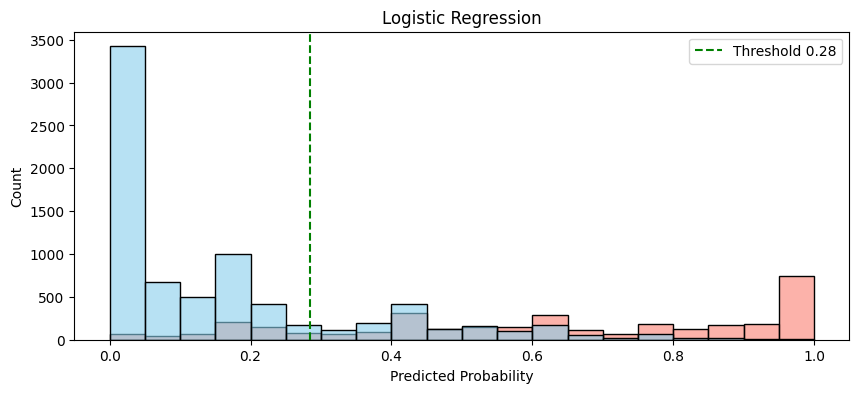

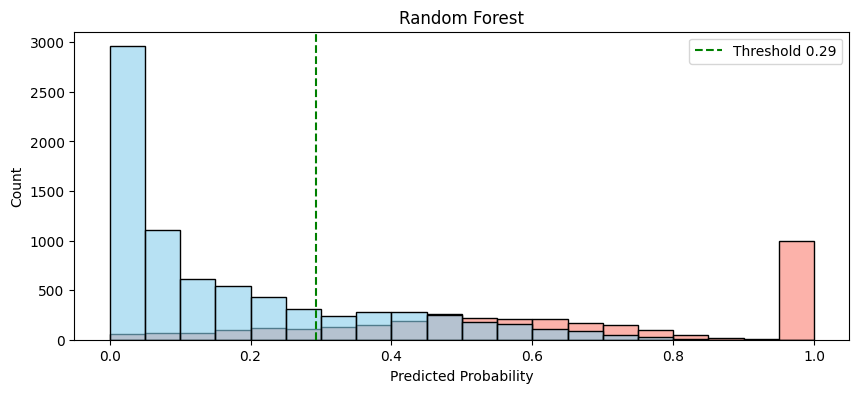

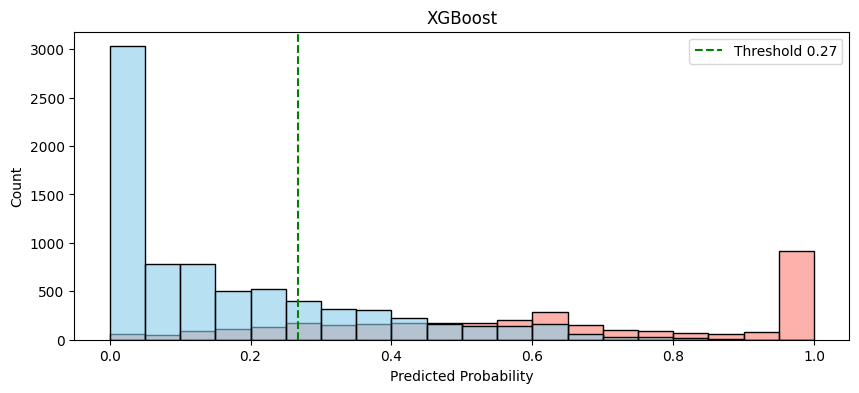


Top 15 features for Logistic Regression:
  Stress Level (1-10): 1.8771 (increases risk)
  Sleep Hours: -0.7585 (decreases risk)
  Therapy Sessions (per month): 0.5317 (increases risk)
  Caffeine Intake (mg/day): 0.4717 (increases risk)
  Occupation_Student: -0.1799 (decreases risk)
  Occupation_Nurse: 0.1442 (increases risk)
  Occupation_Doctor: 0.1421 (increases risk)
  Occupation_Other: 0.1068 (increases risk)
  Medication: 0.0897 (increases risk)
  Recent Major Life Event: 0.0809 (increases risk)
  Occupation_Lawyer: 0.0808 (increases risk)
  Occupation_Athlete: -0.0805 (decreases risk)
  Alcohol Consumption (drinks/week): 0.0738 (increases risk)
  Gender_Other: 0.0733 (increases risk)
  Age: -0.0731 (decreases risk)


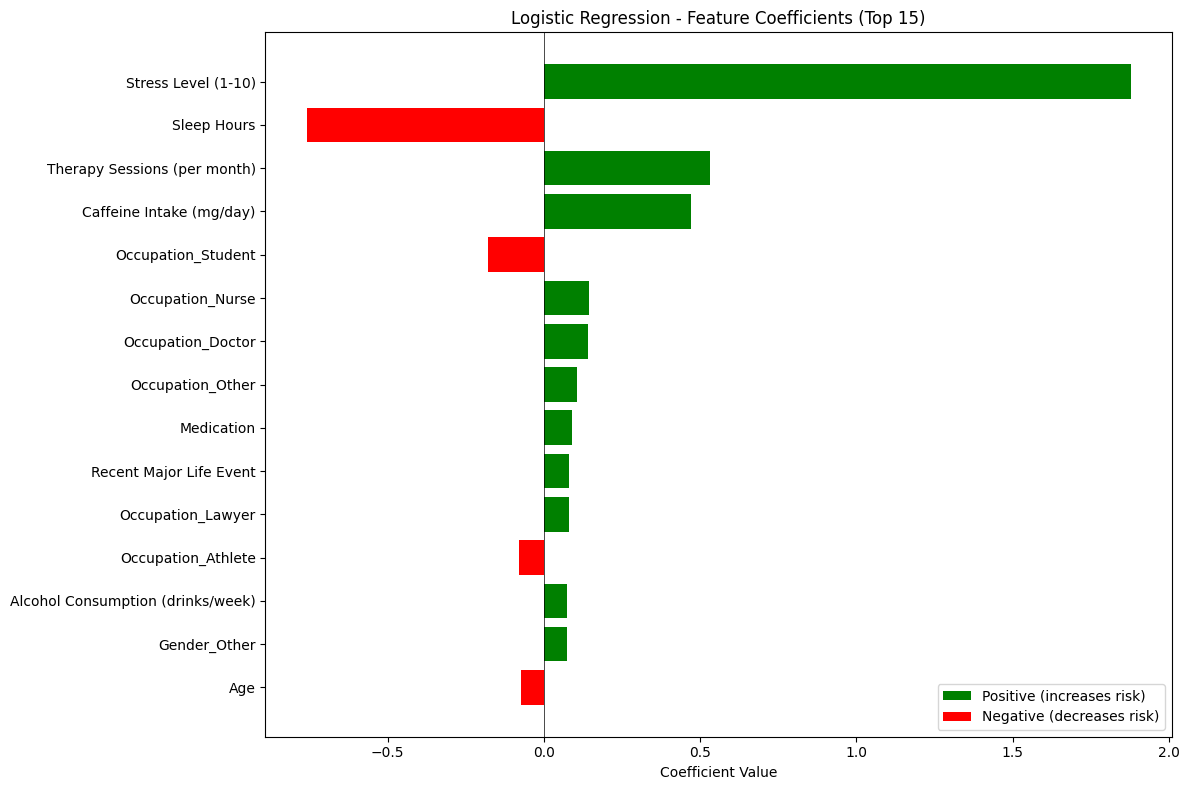


Top 15 features for Random Forest:
  Stress Level (1-10): 0.3114
  Sleep Hours: 0.1086
  Caffeine Intake (mg/day): 0.0850
  Physical Activity (hrs/week): 0.0589
  Therapy Sessions (per month): 0.0552
  Heart Rate (bpm): 0.0536
  Age: 0.0509
  Breathing Rate (breaths/min): 0.0438
  Alcohol Consumption (drinks/week): 0.0428
  Diet Quality (1-10): 0.0404
  Sweating Level (1-5): 0.0271
  Recent Major Life Event: 0.0100
  Medication: 0.0096
  Dizziness: 0.0095
  Gender_Other: 0.0089


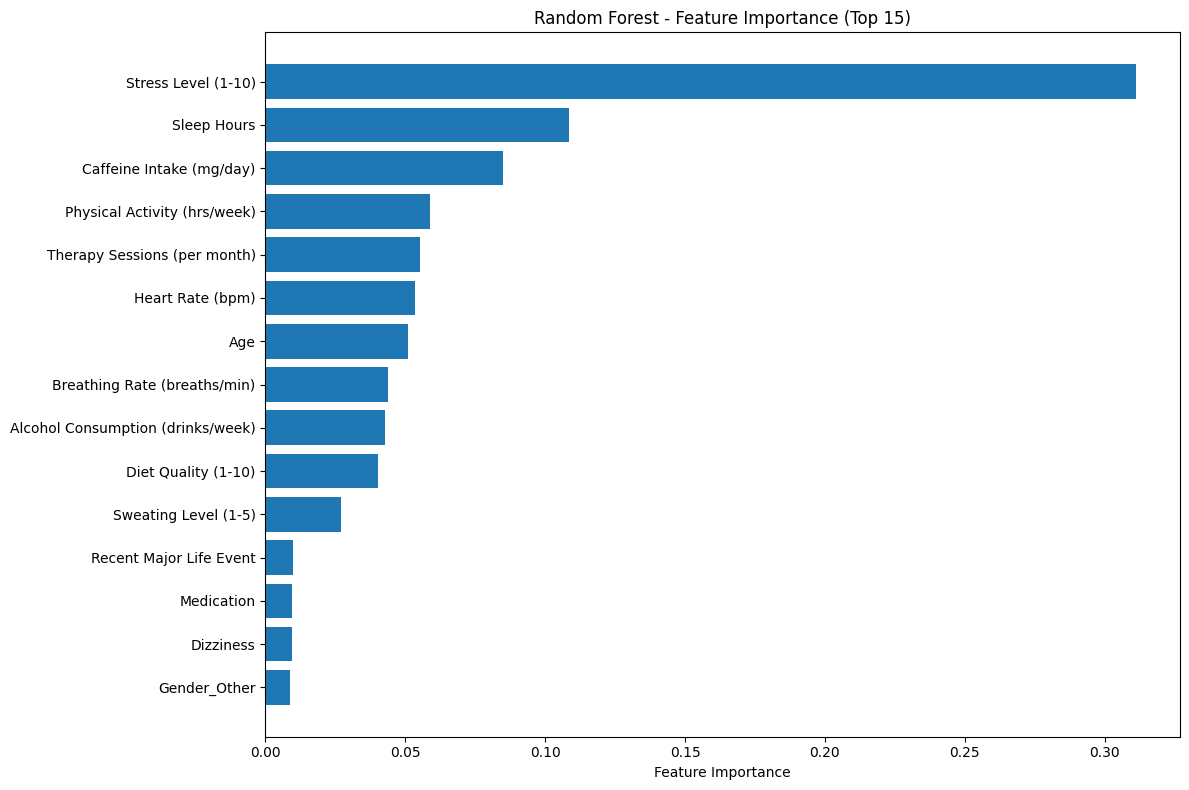


Top 15 features for XGBoost:
  Stress Level (1-10): 0.4402
  Sleep Hours: 0.0664
  Therapy Sessions (per month): 0.0482
  Caffeine Intake (mg/day): 0.0319
  Gender_Male: 0.0246
  Occupation_Athlete: 0.0218
  Occupation_Chef: 0.0201
  Occupation_Scientist: 0.0191
  Sweating Level (1-5): 0.0180
  Alcohol Consumption (drinks/week): 0.0176
  Occupation_Musician: 0.0176
  Diet Quality (1-10): 0.0166
  Occupation_Lawyer: 0.0164
  Age: 0.0162
  Physical Activity (hrs/week): 0.0162


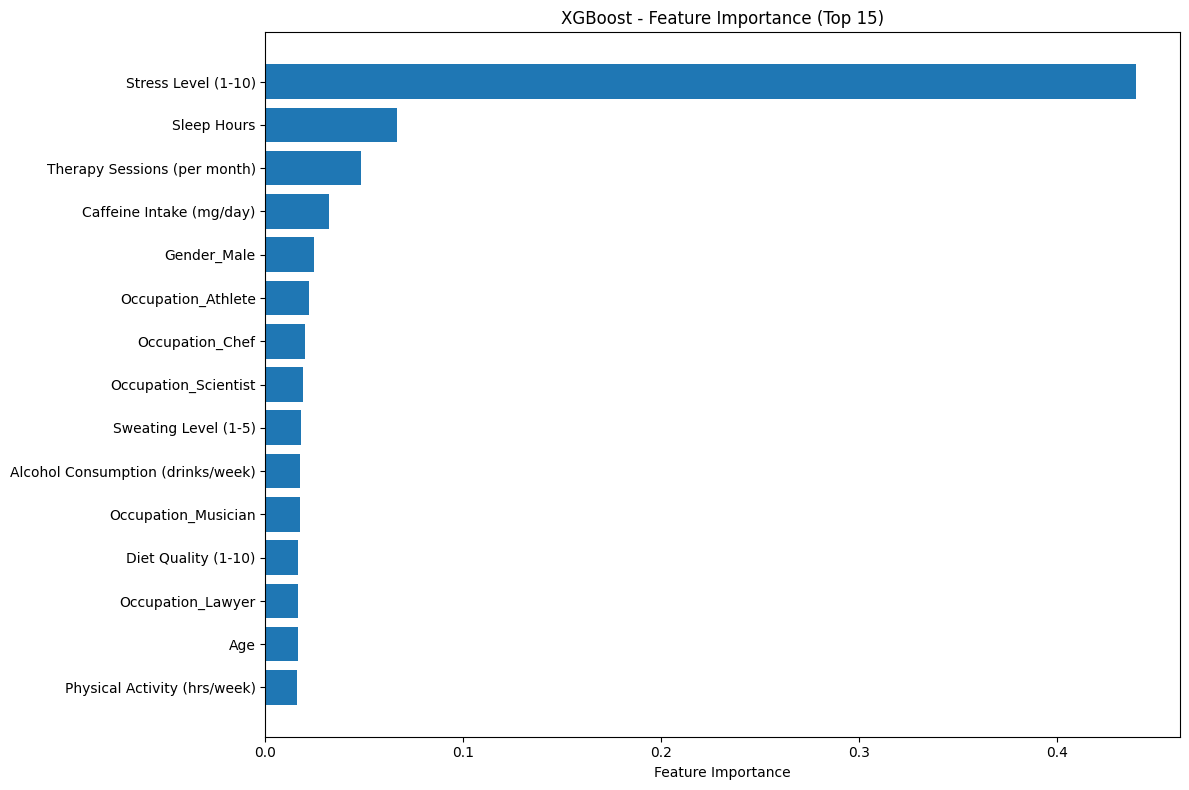


Logistic Regression METRICS (threshold=0.284)
Confusion Matrix:
  True Negatives: 6102
  False Positives: 1516
  False Negatives: 573
  True Positives: 2809

Key Performance Metrics:
  • SENSITIVITY (Recall/True Positive Rate): 0.8306 (83.06%)
  • SPECIFICITY (True Negative Rate): 0.8010 (80.10%)
  • F1-SCORE: 0.7289

Additional Metrics:
  Accuracy: 0.8101 (81.01%)
  Precision: 0.6495 (64.95%)
  ROC AUC: 0.9047
  Brier Score: 0.1114

Classification Report:
              precision    recall  f1-score   support

           0     0.9142    0.8010    0.8538      7618
           1     0.6495    0.8306    0.7289      3382

    accuracy                         0.8101     11000
   macro avg     0.7818    0.8158    0.7914     11000
weighted avg     0.8328    0.8101    0.8154     11000


Random Forest METRICS (threshold=0.293)
Confusion Matrix:
  True Negatives: 5923
  False Positives: 1695
  False Negatives: 510
  True Positives: 2872

Key Performance Metrics:
  • SENSITIVITY (Recall/True Posi

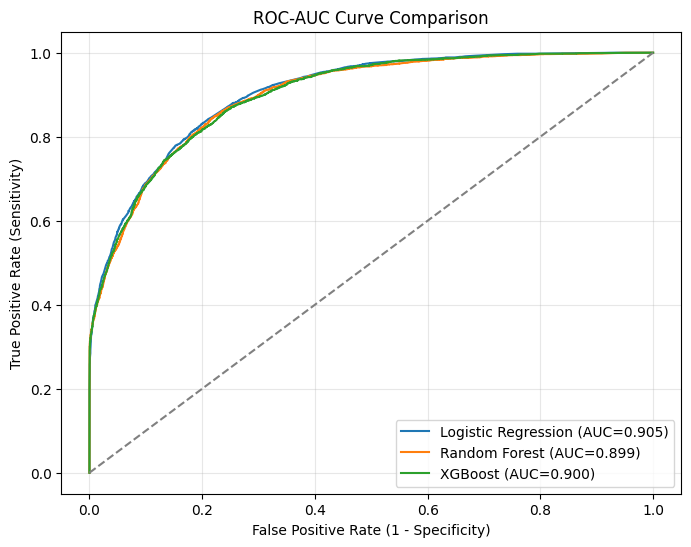

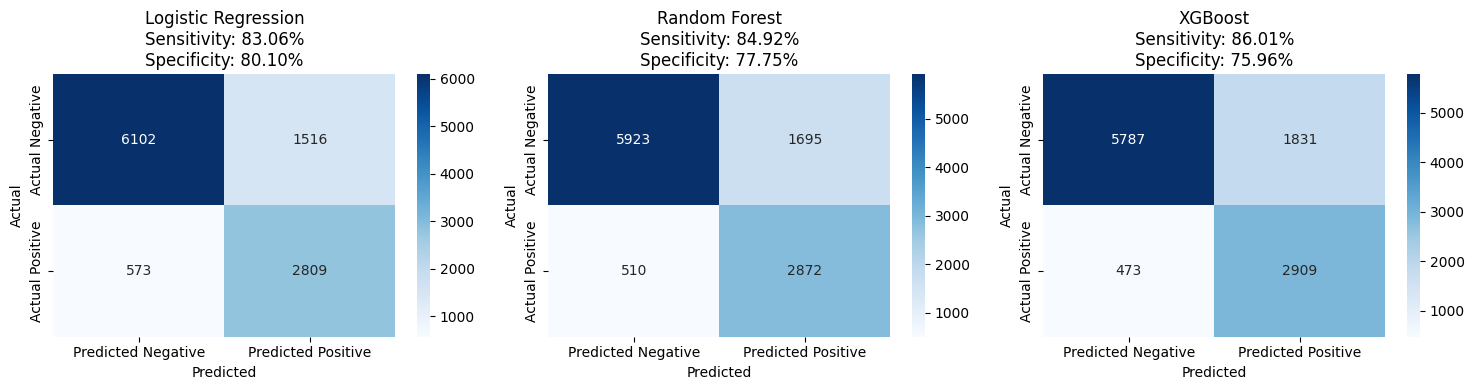

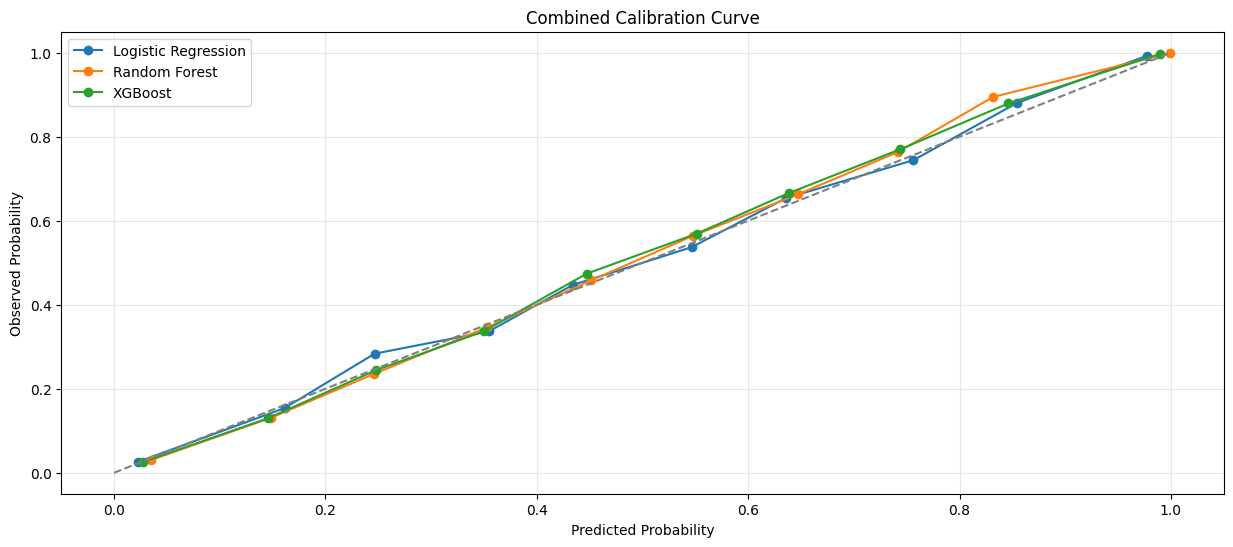


Model saved as predictive_model.pkl


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, accuracy_score, roc_curve, brier_score_loss,
    precision_score, recall_score, f1_score, confusion_matrix, classification_report
)

# Load and prepare training data
train_data = pd.read_csv("training_dataset.csv")
X_train = train_data.drop(columns=["Diagnosed", "Anxiety Level (1-10)"])
y_train = train_data["Diagnosed"]
X_train, y_train = shuffle(X_train, y_train, random_state=42)

# Load and prepare test data
test_data = pd.read_csv("testing_dataset.csv")
X_test = test_data.drop(columns=["Diagnosed", "Anxiety Level (1-10)"])
y_test = test_data["Diagnosed"]

# Identify feature types
numeric_features = X_train.select_dtypes(include=[float, int]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Create preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
])

# Create model pipelines
logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", solver="saga", l1_ratio=0.5, C=1.0))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42))
])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                 eval_metric="logloss", scale_pos_weight=scale_pos_weight, random_state=42))
])

# Calibrate models
logreg_model = CalibratedClassifierCV(logreg_pipeline, method="isotonic", cv=5)
rf_model = CalibratedClassifierCV(rf_pipeline, method="isotonic", cv=5)
xgb_model = CalibratedClassifierCV(xgb_pipeline, method="isotonic", cv=5)

# Train models
logreg_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Get predicted probabilities
logreg_prob = logreg_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Show first 20 predictions
print("\nPredicted probabilities (first 20 patients) with true diagnosis:")
df_probs = pd.DataFrame({
    "Patient": range(1, 21),
    "True Diagnosis": y_test.iloc[:20].values,
    "Logistic Regression (%)": np.round(logreg_prob[:20]*100, 2),
    "Random Forest (%)": np.round(rf_prob[:20]*100, 2),
    "XGBoost (%)": np.round(xgb_prob[:20]*100, 2)
})
print(df_probs)

# Find optimal thresholds
def find_best_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    best_idx = np.argmax(tpr - fpr)
    return thresholds[best_idx]

logreg_threshold = find_best_threshold(y_test, logreg_prob)
rf_threshold = find_best_threshold(y_test, rf_prob)
xgb_threshold = find_best_threshold(y_test, xgb_prob)

# Plot probability distributions
def plot_probabilities_horizontal(y_true, y_prob, threshold, name):
    df = pd.DataFrame({"Probability": y_prob, "Diagnosis": y_true})
    plt.figure(figsize=(10, 4))
    sns.histplot(data=df, x="Probability", hue="Diagnosis", bins=20, palette=["skyblue", "salmon"], alpha=0.6)
    plt.axvline(threshold, color="green", linestyle="--", label=f"Threshold {threshold:.2f}")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.title(name)
    plt.legend()
    plt.show()

plot_probabilities_horizontal(y_test, logreg_prob, logreg_threshold, "Logistic Regression")
plot_probabilities_horizontal(y_test, rf_prob, rf_threshold, "Random Forest")
plot_probabilities_horizontal(y_test, xgb_prob, xgb_threshold, "XGBoost")

# --- FEATURE IMPORTANCE FUNCTION ---
def plot_feature_importance(pipeline_model, name):
    
    classifier = pipeline_model.named_steps["classifier"]

    preprocessor_temp = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
    ])
    preprocessor_temp.fit(X_train)

    numeric_feature_names = numeric_features
    cat_feature_names = preprocessor_temp.named_transformers_["cat"].get_feature_names_out(categorical_features)
    feature_names = list(numeric_feature_names) + list(cat_feature_names)

    plt.figure(figsize=(12, 8))

    if hasattr(classifier, "feature_importances_"):
        importances = classifier.feature_importances_
        indices = np.argsort(importances)[-15:]
        plt.barh(range(len(indices)), importances[indices])
        plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
        plt.xlabel("Feature Importance")
        plt.title(f"{name} - Feature Importance (Top 15)")
        print(f"\nTop 15 features for {name}:")
        for idx in reversed(indices):
            print(f"  {feature_names[idx]}: {importances[idx]:.4f}")

    elif hasattr(classifier, "coef_"):
        coefficients = classifier.coef_[0]
        abs_coef = np.abs(coefficients)
        indices = np.argsort(abs_coef)[-15:]
        colors = ['red' if c < 0 else 'green' for c in coefficients[indices]]
        plt.barh(range(len(indices)), coefficients[indices], color=colors)
        plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
        plt.xlabel("Coefficient Value")
        plt.title(f"{name} - Feature Coefficients (Top 15)")
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='green', label='Positive (increases risk)'),
                           Patch(facecolor='red', label='Negative (decreases risk)')]
        plt.legend(handles=legend_elements, loc='lower right')
        print(f"\nTop 15 features for {name}:")
        for idx in reversed(indices):
            direction = "increases risk" if coefficients[idx] > 0 else "decreases risk"
            print(f"  {feature_names[idx]}: {coefficients[idx]:.4f} ({direction})")

    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()


logreg_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

# Plot feature importance for all models
plot_feature_importance(logreg_pipeline, "Logistic Regression")
plot_feature_importance(rf_pipeline, "Random Forest")
plot_feature_importance(xgb_pipeline, "XGBoost")

# evaluation model
def evaluate_model(y_true, y_prob, threshold, name):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(f"\n{'='*50}")
    print(f"{name} METRICS (threshold={threshold:.3f})")
    print(f"{'='*50}")
    print(f"Confusion Matrix:")
    print(f"  True Negatives: {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives: {tp}")
    print(f"\nKey Performance Metrics:")
    print(f"  • SENSITIVITY (Recall/True Positive Rate): {sensitivity:.4f} ({sensitivity*100:.2f}%)")
    print(f"  • SPECIFICITY (True Negative Rate): {specificity:.4f} ({specificity*100:.2f}%)")
    print(f"  • F1-SCORE: {f1:.4f}")
    print(f"\nAdditional Metrics:")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f} ({prec*100:.2f}%)")
    print(f"  ROC AUC: {roc_auc:.4f}")
    print(f"  Brier Score: {brier:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    return confusion_matrix(y_true, y_pred), {
        'sensitivity': sensitivity,
        'specificity': specificity,
        'f1_score': f1,
        'precision': prec,
        'accuracy': acc,
        'roc_auc': roc_auc
    }

# Evaluate models
logreg_cm, logreg_metrics = evaluate_model(y_test, logreg_prob, logreg_threshold, "Logistic Regression")
rf_cm, rf_metrics = evaluate_model(y_test, rf_prob, rf_threshold, "Random Forest")
xgb_cm, xgb_metrics = evaluate_model(y_test, xgb_prob, xgb_threshold, "XGBoost")

# --- MODEL COMPARISON TABLE ---
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Threshold': [logreg_threshold, rf_threshold, xgb_threshold],
    'Sensitivity (%)': [logreg_metrics['sensitivity']*100, rf_metrics['sensitivity']*100, xgb_metrics['sensitivity']*100],
    'Specificity (%)': [logreg_metrics['specificity']*100, rf_metrics['specificity']*100, xgb_metrics['specificity']*100],
    'F1-Score': [logreg_metrics['f1_score'], rf_metrics['f1_score'], xgb_metrics['f1_score']],
    'Precision (%)': [logreg_metrics['precision']*100, rf_metrics['precision']*100, xgb_metrics['precision']*100],
    'Accuracy (%)': [logreg_metrics['accuracy']*100, rf_metrics['accuracy']*100, xgb_metrics['accuracy']*100],
    'ROC-AUC': [logreg_metrics['roc_auc'], rf_metrics['roc_auc'], xgb_metrics['roc_auc']]
}).round(2)

print("\nMODEL COMPARISON SUMMARY\n", comparison_df.to_string(index=False))

# --- ROC Curve ---
plt.figure(figsize=(8,6))
for prob, label in zip([logreg_prob, rf_prob, xgb_prob], ["Logistic Regression", "Random Forest", "XGBoost"]):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})")
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC-AUC Curve Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- CONFUSION MATRICES ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sensitivity_labels = [
    f"Sensitivity: {logreg_metrics['sensitivity']:.2%}\nSpecificity: {logreg_metrics['specificity']:.2%}",
    f"Sensitivity: {rf_metrics['sensitivity']:.2%}\nSpecificity: {rf_metrics['specificity']:.2%}",
    f"Sensitivity: {xgb_metrics['sensitivity']:.2%}\nSpecificity: {xgb_metrics['specificity']:.2%}"
]
for idx, (cm, ax, label) in enumerate(zip([logreg_cm, rf_cm, xgb_cm], axes, sensitivity_labels)):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, 
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{['Logistic Regression', 'Random Forest', 'XGBoost'][idx]}\n{label}")
plt.tight_layout()
plt.show()

# --- CALIBRATION CURVES ---
plt.figure(figsize=(15,6))
for prob, label in zip([logreg_prob, rf_prob, xgb_prob], ["Logistic Regression", "Random Forest", "XGBoost"]):
    prob_true, prob_pred = calibration_curve(y_test, prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=label)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title("Combined Calibration Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Save model
joblib.dump(xgb_model, 'predictive_model.pkl', compress=3)
print("\nModel saved as predictive_model.pkl")